# PoliMillionaire — Kaggle live-play

Linear flow: **bootstrap → retrieval → LLM → play → persist**.
Set `COMPETITIONS` in the play cell to pick one or all four. The two
*Optional dev tools* cells in the middle are only used when iterating
on prompts; skip them for a normal run.

## 1. Bootstrap

Credentials, repo clone/pull, dependency install, indices symlink,
question-log pull from the Kaggle Dataset.

In [1]:
# --- Authenticate internal Kaggle API (New Token Format) ---
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
os.environ["KAGGLE_API_TOKEN"] = secrets.get_secret("KAGGLE_API_TOKEN")


In [2]:
import importlib.util
import os
import sys
from pathlib import Path

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# --- Secrets & Auth --------------------------------------------------------
secrets = UserSecretsClient()
os.environ["KAGGLE_API_TOKEN"] = secrets.get_secret("KAGGLE_API_TOKEN")
gh_token = secrets.get_secret("GH_TOKEN")
os.environ["POLIMILLIONAIRE_API_URL"] = secrets.get_secret("POLIMILLIONAIRE_API_URL")
os.environ["POLIMILLIONAIRE_USER"] = secrets.get_secret("POLIMILLIONAIRE_USER")
os.environ["POLIMILLIONAIRE_PASSWORD"] = secrets.get_secret("POLIMILLIONAIRE_PASSWORD")
login(token=secrets.get_secret("HF_TOKEN"), add_to_git_credential=False)

# --- Repo: clone or fast-forward main --------------------------------------
REPO_DIR = Path("/kaggle/working/polimillionaire")
if REPO_DIR.exists():
    os.chdir(REPO_DIR)
    !git checkout -q main && git pull --ff-only origin main
else:
    !git clone -q https://{gh_token}@github.com/leonfuss/polimillionaire.git {REPO_DIR}
    os.chdir(REPO_DIR)

# --- Deps: install only what Kaggle's base image is missing ----------------
NEEDED = {
    "sentence_transformers": "sentence-transformers",
    "faiss": "faiss-cpu",
    "bm25s": "bm25s",
    "polars": "polars",
    "dotenv": "python-dotenv",
    "sympy": "sympy",
}
missing = [pkg for mod, pkg in NEEDED.items() if importlib.util.find_spec(mod) is None]
if missing:
    !pip install -q {" ".join(missing)}

if importlib.util.find_spec("llama_cpp") is None:
    !pip install -q llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

# --- Project install (editable, no deps) -----------------------------------
!pip install -q -e {REPO_DIR} --no-deps
if str(REPO_DIR / "src") not in sys.path:
    sys.path.insert(0, str(REPO_DIR / "src"))

# --- Indices ---------------------------------------------------------------
INDEX_CANDIDATES = [
    Path("/kaggle/input/polimillionaire-indices"),
    Path("/kaggle/input/datasets/leonfuss/polimillionaire-indices"),
]
INDEX_SRC = next((p for p in INDEX_CANDIDATES if p.exists()), None)
INDEX_DST = REPO_DIR / "data" / "index"
INDEX_DST.parent.mkdir(parents=True, exist_ok=True)
if INDEX_SRC is not None and not INDEX_DST.exists():
    INDEX_DST.symlink_to(INDEX_SRC)

# --- Question log: API Pull from New Target --------------------------------
from polimillionaire.kaggle_db import pull_db  

db_path = pull_db(
    dataset_id="toniorangina/polimillionaire4", 
    target_path="/kaggle/working/questions.sqlite"
)
os.environ["POLIMILLIONAIRE_DB_PATH"] = str(db_path)

# --- Sanity ----------------------------------------------------------------
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
print("indices:", sorted(p.name for p in (INDEX_DST.iterdir() if INDEX_DST.exists() else [])))
print("DB at:  ", db_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 64.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 GB 957.2 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for polimillionaire (pyproject.toml) ... done
Dataset URL: https://www.kaggle.com/datasets/toniorangina/polimillionaire4


100%|██████████| 2.93M/2.93M [00:00<00:00, 160MB/s]


Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


indices: ['math', 'wiki_entertainment', 'wiki_history', 'wiki_science']
DB at:   /kaggle/working/questions.sqlite


## 2. Retrieval models on `cuda:1`

Pin embedders + reranker to the second T4 so they don't fight
llama.cpp on `cuda:0`. ~10× faster reranking than CPU and zero
contention with the LLM.

In [3]:
from polimillionaire.retrieval.embedder import Embedder
from polimillionaire.retrieval.reranker import DEFAULT_RERANKER, Reranker
from polimillionaire.strategies import factory

RETRIEVAL_DEVICE = "cuda:1"
for model in ("BAAI/bge-base-en-v1.5", "BAAI/bge-small-en-v1.5"):
    factory._embedder_cache[model] = Embedder(model, device=RETRIEVAL_DEVICE)
factory._reranker_cache[DEFAULT_RERANKER] = Reranker(DEFAULT_RERANKER, device=RETRIEVAL_DEVICE)
print("retrieval on", RETRIEVAL_DEVICE)

retrieval on cuda:1


## 3. Imports

In [4]:
# 1. Standard Library
import gc
import json
import sqlite3
from dataclasses import asdict
from pathlib import Path

# 2. Third-Party Libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

# 3. Internal / Polimillionaire Framework
from polimillionaire import make_client, preload
from polimillionaire._vendor.millionaire_client.models import Option, Question
from polimillionaire.eval.replay import _aggregate, print_summary, replay
from polimillionaire.eval.results import ReplayResult
from polimillionaire.llm import MODELS, ModelSpec, load_llm, unload
from polimillionaire.play import auto_play_loop
from polimillionaire.strategies.base import Context
from polimillionaire.strategies.factory import make_strategy
from polimillionaire.strategies.zero_shot import ZeroShotStrategy

# MonkeyPatch

In [5]:
import json
from polimillionaire.llm import LLM

# --- 1. Memory Injection: Robust JSON Parser ---
def safe_complete_json(self, messages, schema, *, temperature=0.2, max_tokens=256, **kwargs):
    from llama_cpp import LlamaGrammar
    
    grammar = LlamaGrammar.from_json_schema(json.dumps(schema))
    out = self._inner.create_chat_completion(
        messages=self._prepare(messages),
        temperature=temperature,
        max_tokens=max_tokens,
        grammar=grammar,
        **kwargs,
    )
    raw = out["choices"][0]["message"]["content"]
    
    try:
        # strict=False allows Python to parse literal \n and \t inside JSON strings
        return json.loads(raw, strict=False)
    except json.JSONDecodeError:
        # Aggressive sanitation for Math model hallucinations
        sanitized = raw.replace('\n', '\\n').replace('\r', '').replace('\t', '\\t')
        try:
            return json.loads(sanitized, strict=False)
        except json.JSONDecodeError:
            # Fatal collapse. Return a dummy dictionary to prevent the loop from dying.
            print("\n    [!] FATAL PARSE ERROR: Model hallucinated invalid JSON. Injecting dummy fallback to save harvest loop.")
            
            # Dynamically infer the expected keys from the Pydantic schema
            fallback = {}
            for key, props in schema.get("properties", {}).items():
                val_type = props.get("type", "string")
                if val_type == "integer": fallback[key] = 0
                elif val_type == "number": fallback[key] = 0.0
                elif val_type == "boolean": fallback[key] = False
                else: fallback[key] = "Parse Failure."
            return fallback

# --- 2. Override the Repository Class ---
LLM.complete_json = safe_complete_json
print("[SYSTEM] LLM.complete_json successfully monkey-patched. Execution loop is now crash-proof.")

[SYSTEM] LLM.complete_json successfully monkey-patched. Execution loop is now crash-proof.


# Choice of the best models (per competitions)

To simultaneously harvest some questions data and empirically try our model-strategy pairs, we executed every model-strategy configuration for a minimum of N = 20 live API sessions, logging the results to our SQLite database. All the data from the runs :  latency, structural failures, and progression was recorded in the database. 

To isolate the top performing configurations per domain for exhaustive offline evaluation on the database we used different metrics.

Performance evaluation was anchored strictly on the median level reached rather than the mean. Because the live API sample size per configuration is relatively small, the mean is highly susceptible to right-skewed variance; a single statistically anomalous run reaching Level 15 artificially distorts the average, projecting false confidence in an unstable model. The median provides a mathematically robust, outlier-resistant baseline. Then we also looked at the  maximum level reached because the goal ultimately is to reach the level 15 sometimes and not just have the higest median. 

## Math

In [27]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COMP_ID = 3  # Target strictly Math domain

db_path = "/kaggle/working/questions.sqlite"
con = sqlite3.connect(db_path)

# Query A: Progression Metrics isolated to target domain (Native Strategies Only)
query_progression = f"""
SELECT 
    model_name || '_' || strategy_name AS combo_name,
    session_id,
    MAX(level) AS max_level_reached
FROM predictions
WHERE competition_id = {TARGET_COMP_ID} 
  AND strategy_name != 'db_retrieval'
GROUP BY combo_name, session_id;
"""
df_progression = pd.read_sql(query_progression, con)

df_levels = df_progression.groupby('combo_name').agg(
    median_level=('max_level_reached', 'median'),
    absolute_max_level=('max_level_reached', 'max')
).reset_index()

# Query B: Telemetry isolated to target domain (Native Strategies Only)
query_telemetry = f"""
SELECT 
    model_name || '_' || strategy_name AS combo_name,
    CASE 
        WHEN rationale LIKE '%timed out%' THEN 'timeout'
        WHEN rationale LIKE '%Exception%' OR rationale LIKE '%parse%' THEN 'parse_error'
        WHEN predicted_option_id = correct_option_id_if_known THEN 'success'
        ELSE 'wrong'
    END AS failure_mode,
    latency_ms,
    CASE WHEN predicted_option_id = correct_option_id_if_known THEN 1 ELSE 0 END AS correct
FROM predictions
WHERE mode = 'text' 
  AND competition_id = {TARGET_COMP_ID}
  AND strategy_name != 'db_retrieval'; 
"""
df_tel = pd.read_sql(query_telemetry, con)
con.close()

df_stats = df_tel.groupby('combo_name').agg(
    n_trials=('correct', 'count'),
    n_correct=('correct', 'sum'),
    mean_latency_s=('latency_ms', lambda x: x.mean() / 1000.0)
).reset_index()
df_stats['win_rate'] = df_stats['n_correct'] / df_stats['n_trials']

df_final = pd.merge(df_levels, df_stats, on='combo_name')
df_final = df_final.sort_values('median_level', ascending=False)

print(f"[SYSTEM] Data isolated for Competition ID: {TARGET_COMP_ID}. DB Wrappers purged. Matrix ready.")

[SYSTEM] Data isolated for Competition ID: 3. DB Wrappers purged. Matrix ready.


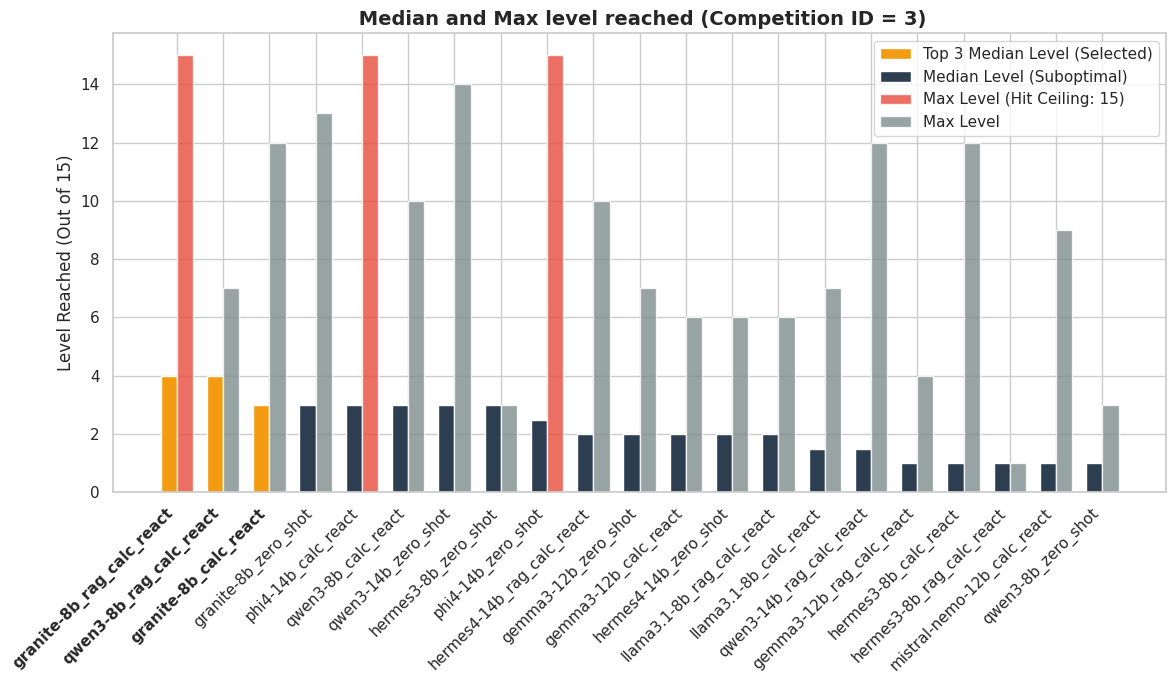

In [33]:
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(df_final))
width = 0.35

# 1. Define conditional colors
# Top 3 Median get Gold/Orange, the rest get Dark Navy
median_colors = ['#f39c12' if i < 3 else '#2c3e50' for i in range(len(df_final))]
# Max Level gets Red if it hit the ceiling (15), otherwise Grey
max_colors = ['#e74c3c' if val == 15 else '#7f8c8d' for val in df_final['absolute_max_level']]

# 2. Plot the bars using the color arrays
ax1.bar(x - width/2, df_final['median_level'], width, color=median_colors)
ax1.bar(x + width/2, df_final['absolute_max_level'], width, color=max_colors, alpha=0.8)

# 3. Format the X-Axis
ax1.set_xticks(x)
xticklabels = ax1.set_xticklabels(df_final['combo_name'], rotation=45, ha='right', fontsize=11)

# Make the text labels bold for the Top 3 to reinforce the visual hierarchy
for i in range(min(3, len(xticklabels))):
    xticklabels[i].set_fontweight('bold')

ax1.set_ylabel("Level Reached (Out of 15)", fontsize=12)
ax1.set_title(f" Median and Max level reached (Competition ID = {TARGET_COMP_ID})", fontsize=14, fontweight='bold')

# 4. Build a custom legend so the new colors are explained
legend_elements = [
    Patch(facecolor='#f39c12', label='Top 3 Median Level (Selected)'),
    Patch(facecolor='#2c3e50', label='Median Level (Suboptimal)'),
    Patch(facecolor='#e74c3c', alpha=0.8, label='Max Level (Hit Ceiling: 15)'),
    Patch(facecolor='#7f8c8d', alpha=0.8, label='Max Level')
]
ax1.legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

For each model, we analyzed the failure modes—parse errors, timeouts, or incorrect answers—and selected only those free of parsing errors and timeouts.

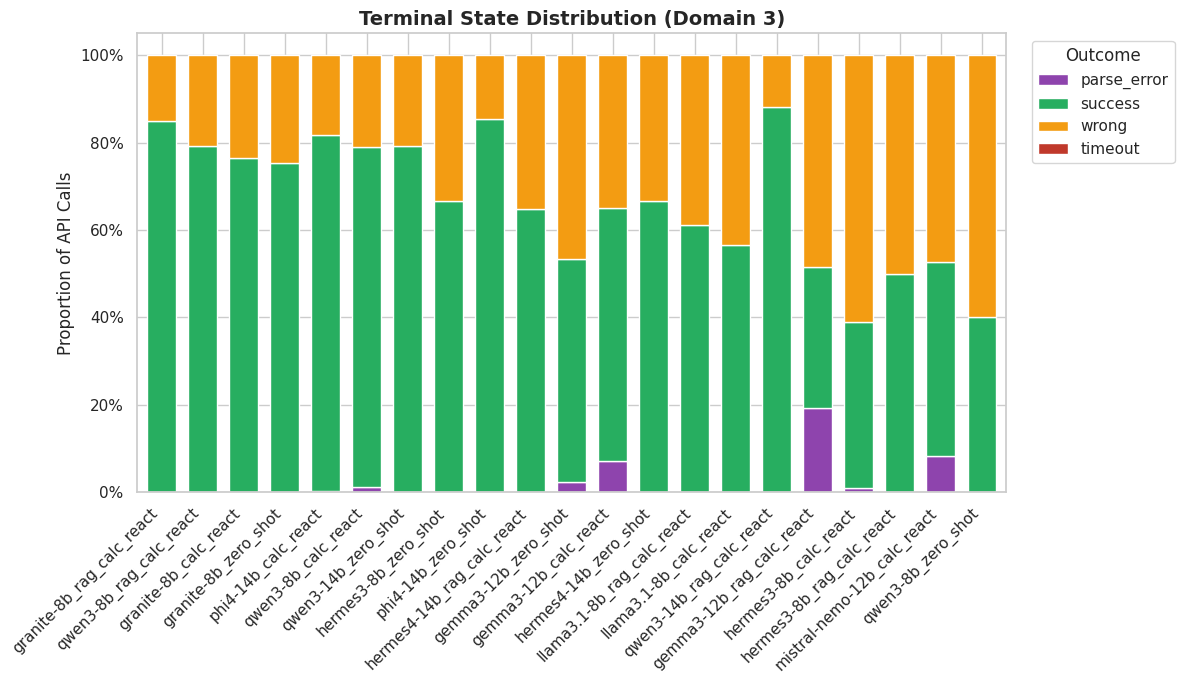

In [35]:
fig, ax3 = plt.subplots(figsize=(12, 7))

state_counts = df_tel.groupby(['combo_name', 'failure_mode']).size().unstack(fill_value=0)
# Ensure columns exist even if zero occurrences in this domain
for col in ['success', 'wrong', 'timeout', 'parse_error']:
    if col not in state_counts.columns:
        state_counts[col] = 0

state_pct = state_counts.div(state_counts.sum(axis=1), axis=0).reindex(df_final['combo_name'])

colors = {'success': '#27ae60', 'wrong': '#f39c12', 'timeout': '#c0392b', 'parse_error': '#8e44ad'}
plot_colors = [colors[c] for c in state_pct.columns]

state_pct.plot(kind='bar', stacked=True, color=plot_colors, ax=ax3, width=0.7)

ax3.set_title(f"Terminal State Distribution (Domain {TARGET_COMP_ID})", fontsize=14, fontweight='bold')
ax3.set_xlabel("")
ax3.set_ylabel("Proportion of API Calls", fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax3.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
ax3.set_xticklabels(state_pct.index, rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

To select the best models for the Math competition, we tested all combinations in live games and immediately removed any that crashed or ran out of time. For the models that survived, we judged them based on their median score (which shows reliable, consistent performance) and their maximum level reached (which proves they can solve the hardest late-game questions). Our top choice was granite8b_rag_calc_react because it had the best overall median and successfully reached the final level (Level 15). We rejected qwen3-8b_rag_calc_react; although it had the second-best median, it never made it past Level 6. To round out our top three, we selected qwen3-14b_zero_shot and phi4-14b_calc_react. Both of these models offered a great compromise, delivering strong, consistent median scores while still proving capable of reaching Level 15.

## Philosophy

In [48]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COMP_ID = 4  # Target strictly Math domain

db_path = "/kaggle/working/questions.sqlite"
con = sqlite3.connect(db_path)

# Query A: Progression Metrics isolated to target domain (Native Strategies Only)
query_progression = f"""
SELECT 
    model_name || '_' || strategy_name AS combo_name,
    session_id,
    MAX(level) AS max_level_reached
FROM predictions
WHERE competition_id = {TARGET_COMP_ID} 
  AND strategy_name != 'db_retrieval'
GROUP BY combo_name, session_id;
"""
df_progression = pd.read_sql(query_progression, con)

df_levels = df_progression.groupby('combo_name').agg(
    median_level=('max_level_reached', 'median'),
    absolute_max_level=('max_level_reached', 'max')
).reset_index()

# Query B: Telemetry isolated to target domain (Native Strategies Only)
query_telemetry = f"""
SELECT 
    model_name || '_' || strategy_name AS combo_name,
    CASE 
        WHEN rationale LIKE '%timed out%' THEN 'timeout'
        WHEN rationale LIKE '%Exception%' OR rationale LIKE '%parse%' THEN 'parse_error'
        WHEN predicted_option_id = correct_option_id_if_known THEN 'success'
        ELSE 'wrong'
    END AS failure_mode,
    latency_ms,
    CASE WHEN predicted_option_id = correct_option_id_if_known THEN 1 ELSE 0 END AS correct
FROM predictions
WHERE mode = 'text' 
  AND competition_id = {TARGET_COMP_ID}
  AND strategy_name != 'db_retrieval'; 
"""
df_tel = pd.read_sql(query_telemetry, con)
con.close()

df_stats = df_tel.groupby('combo_name').agg(
    n_trials=('correct', 'count'),
    n_correct=('correct', 'sum'),
    mean_latency_s=('latency_ms', lambda x: x.mean() / 1000.0)
).reset_index()
df_stats['win_rate'] = df_stats['n_correct'] / df_stats['n_trials']

df_final = pd.merge(df_levels, df_stats, on='combo_name')
df_final = df_final.sort_values('median_level', ascending=False)

print(f"[SYSTEM] Data isolated for Competition ID: {TARGET_COMP_ID}. DB Wrappers purged. Matrix ready.")

[SYSTEM] Data isolated for Competition ID: 4. DB Wrappers purged. Matrix ready.


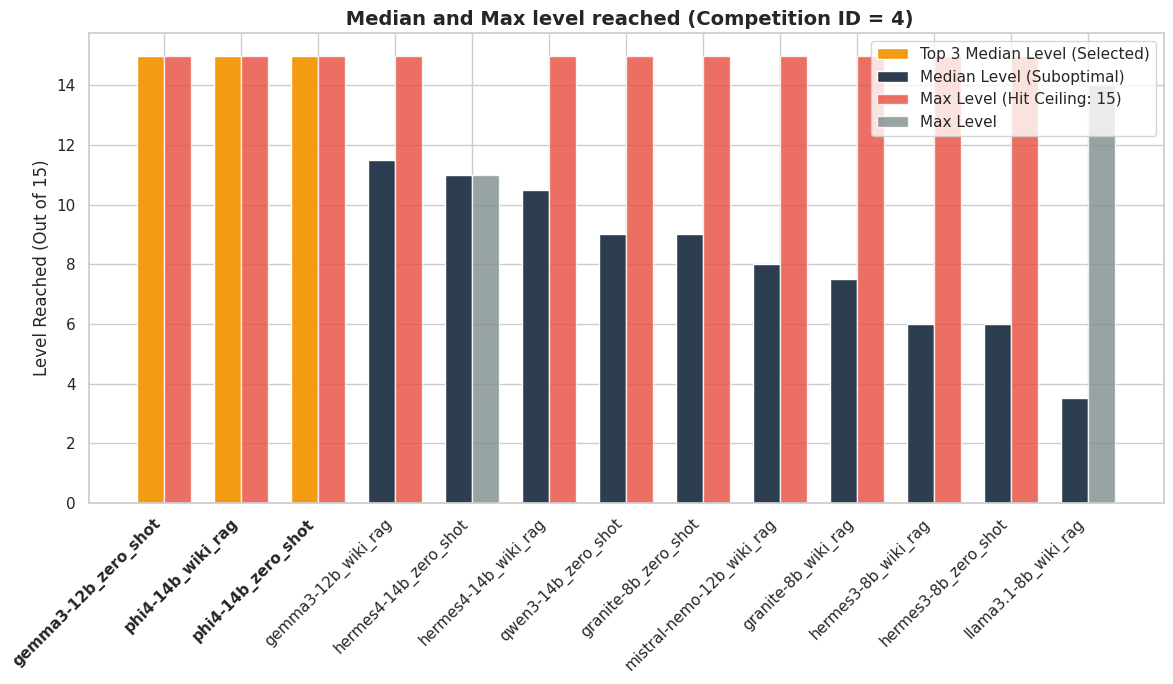

In [49]:
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

x = np.arange(len(df_final))
width = 0.35

# 1. Define conditional colors
# Top 3 Median get Gold/Orange, the rest get Dark Navy
median_colors = ['#f39c12' if i < 3 else '#2c3e50' for i in range(len(df_final))]
# Max Level gets Red if it hit the ceiling (15), otherwise Grey
max_colors = ['#e74c3c' if val == 15 else '#7f8c8d' for val in df_final['absolute_max_level']]

# 2. Plot the bars using the color arrays
ax1.bar(x - width/2, df_final['median_level'], width, color=median_colors)
ax1.bar(x + width/2, df_final['absolute_max_level'], width, color=max_colors, alpha=0.8)

# 3. Format the X-Axis
ax1.set_xticks(x)
xticklabels = ax1.set_xticklabels(df_final['combo_name'], rotation=45, ha='right', fontsize=11)

# Make the text labels bold for the Top 3 to reinforce the visual hierarchy
for i in range(min(3, len(xticklabels))):
    xticklabels[i].set_fontweight('bold')

ax1.set_ylabel("Level Reached (Out of 15)", fontsize=12)
ax1.set_title(f" Median and Max level reached (Competition ID = {TARGET_COMP_ID})", fontsize=14, fontweight='bold')

# 4. Build a custom legend so the new colors are explained
legend_elements = [
    Patch(facecolor='#f39c12', label='Top 3 Median Level (Selected)'),
    Patch(facecolor='#2c3e50', label='Median Level (Suboptimal)'),
    Patch(facecolor='#e74c3c', alpha=0.8, label='Max Level (Hit Ceiling: 15)'),
    Patch(facecolor='#7f8c8d', alpha=0.8, label='Max Level')
]
ax1.legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

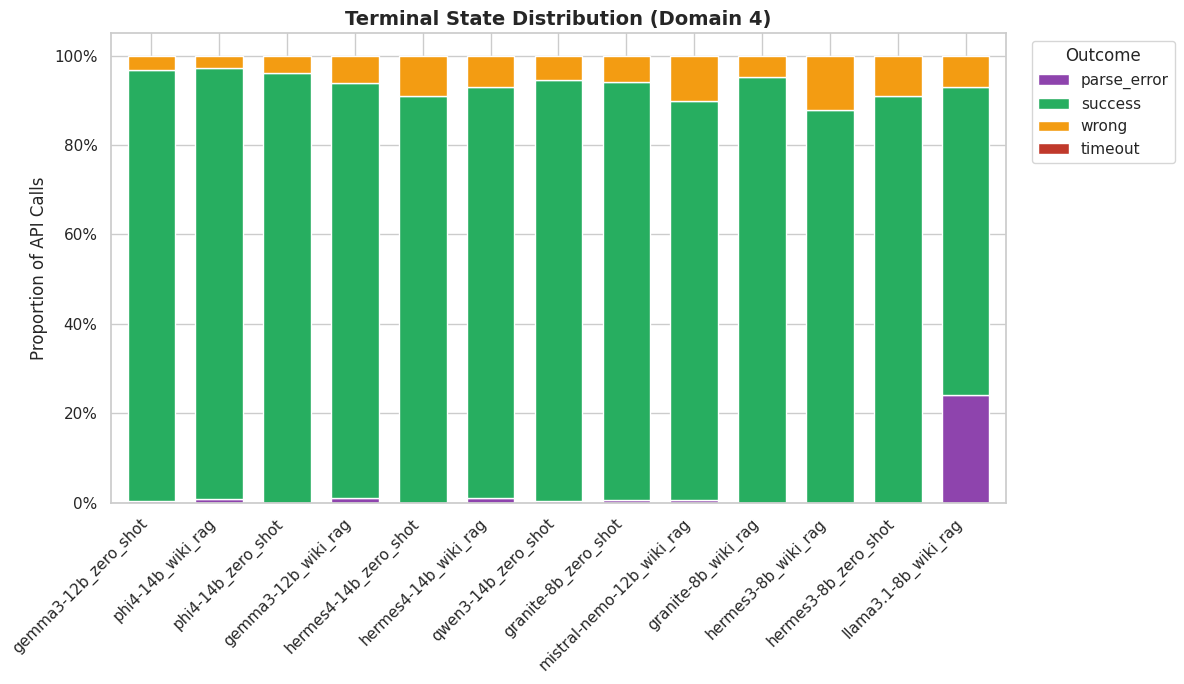

In [50]:
fig, ax3 = plt.subplots(figsize=(12, 7))

state_counts = df_tel.groupby(['combo_name', 'failure_mode']).size().unstack(fill_value=0)
# Ensure columns exist even if zero occurrences in this domain
for col in ['success', 'wrong', 'timeout', 'parse_error']:
    if col not in state_counts.columns:
        state_counts[col] = 0

state_pct = state_counts.div(state_counts.sum(axis=1), axis=0).reindex(df_final['combo_name'])

colors = {'success': '#27ae60', 'wrong': '#f39c12', 'timeout': '#c0392b', 'parse_error': '#8e44ad'}
plot_colors = [colors[c] for c in state_pct.columns]

state_pct.plot(kind='bar', stacked=True, color=plot_colors, ax=ax3, width=0.7)

ax3.set_title(f"Terminal State Distribution (Domain {TARGET_COMP_ID})", fontsize=14, fontweight='bold')
ax3.set_xlabel("")
ax3.set_ylabel("Proportion of API Calls", fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax3.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
ax3.set_xticklabels(state_pct.index, rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.show()

In the Philosophy domain, zero-shot performance improved significantly. We retained three configurations—Phi-4-14B (Wiki-RAG), Gemma-3-12B (Zero-Shot), and Phi-4-14B (Zero-Shot)—which achieved a median score of 15.

The performance gap between Philosophy and domains like Entertainment or Mathematics is driven by vocabulary specificity. Philosophy relies on highly technical, rare terms (e.g., "Tractatus," "Abduction") that form tight, isolated clusters in a language model's memory. Because these words rarely appear outside their specific academic contexts, they act as strong discriminators, allowing the model to easily map the question to the correct answer with high confidence. In contrast, Entertainment trivia uses common, everyday words that appear across millions of unrelated texts, creating noisy, overlapping data patterns where the model struggles to find a clear preference. Meanwhile, Mathematics fails for a different reason: it requires fragile, multi-step symbolic logic where a single mistake breaks the entire calculation, whereas Philosophy only requires static word-matching. 

Iterating this selection process across all domains yielded the final model configurations detailed below.

| Competition ID | Model | Paradigm |
| :--- | :--- | :--- |
| **0** | Phi-4-14B <br> Gemma-3-12B <br> Qwen-3-14B | Zero-Shot <br> Zero-Shot <br> Wiki-RAG |
| **1** | Granite-8B <br> Phi-4-14B <br> Gemma-3-12B | Wiki-RAG <br> Zero-Shot <br> Wiki-RAG |
| **2** | Qwen-3-14B <br> Phi-4-14B <br> Gemma-3-12B | Zero-Shot <br> Zero-Shot <br> Wiki-RAG |
| **3** | Granite-8B <br> Qwen-3-14B <br> Phi-4-14B | RAG-Calc-ReAct <br> Zero-Shot <br> Calc-ReAct |
| **4** | Phi-4-14B <br> Gemma-3-12B <br> Phi-4-14B | Wiki-RAG <br> Zero-Shot <br> Zero-Shot |
| **5** | TODO <br> TODOB <br>TODO | TODOt <br> TODO <br>  TODO |

# Notebook replay function

The functions below optimize pipeline latency by implementing selective state replay rather than re-executing the full database sequence. 

This optimization is necessary to bypass severe compute bottlenecks; for example, inference with `Qwen-8B` exhibits a high latency profile (~8s per query). By isolating and replaying only a subset of questions we reduce drastically the run time

In [6]:
def nb_replay2(strategy, log_path, competition_id=None, limit=None):
    import sqlite3
    import json
    from tqdm import tqdm
    from polimillionaire._vendor.millionaire_client.models import Option, Question
    from polimillionaire.eval.results import ReplayResult
    from polimillionaire.strategies.base import Context
    
    # 1. Fetch and close immediately. Do not hold DB locks during inference.
    with sqlite3.connect(log_path) as con:
        con.row_factory = sqlite3.Row
        
        sql = """
            WITH RankedPredictions AS (
                SELECT question_id, question_text, options_json, level, 
                       competition_id, correct_option_id_if_known, generated_answer,
                       ROW_NUMBER() OVER(PARTITION BY question_id ORDER BY id DESC) as rn
                FROM predictions
                WHERE correct_option_id_if_known IS NOT NULL
        """
        params = []
        
        if competition_id is not None:
            sql += " AND competition_id = ?"
            params.append(competition_id)
            
        sql += """
            )
            SELECT * FROM RankedPredictions WHERE rn = 1
            ORDER BY question_id  -- CRITICAL: Deterministic sorting for reliable ablation
        """
        
        if limit is not None:
            sql += " LIMIT ?"
            params.append(limit)
            
        cur = con.execute(sql, params)
        rows = cur.fetchall()

    results = []
    
    for row in tqdm(rows, desc=f"Evaluating Domain {competition_id}"):
        options = [Option(**o) for o in json.loads(row["options_json"])]
        question = Question(id=row["question_id"], text=row["question_text"], options=options, level=row["level"])
        ctx = Context(competition_id=row["competition_id"], level=row["level"])
        
        decision = strategy(question, ctx)
        correct_id = int(row["correct_option_id_if_known"])
        
        # Safely parse SQLite mixed-type booleans
        raw_gen = row["generated_answer"]
        is_generated = raw_gen in (1, '1', 'true', 'True', True)
        
        results.append(ReplayResult(
            strategy_name=decision.strategy_name, 
            model_name=decision.model_name, 
            prompt_version=decision.prompt_version, 
            question_id=row["question_id"], 
            competition_id=row["competition_id"], 
            level=row["level"],
            predicted_option_id=decision.option_id, 
            correct_option_id=correct_id, 
            correct=(decision.option_id == correct_id), 
            confidence=decision.confidence, 
            latency_ms=decision.latency_ms, 
            generated_answer=is_generated
        ))

    return results

## Why Replaying against the database ? 

Evaluating llms directly against the live competitive API is operationally necessary for data harvesting, but unsatisfactory for comparative study of models. To strictly isolate architectural performance from environmental noise, we transitioned our primary evaluation pipeline to a deterministic database replay mechanism. This offline architecture guarantees 2 critical  advantages:

**1. Identical Test Set**
Live API evaluation introduces environmental variance via stochastic question sequencing. If Model A outperforms Model B, the delta may reflect asymmetric question difficulty rather than architectural superiority. Replaying from a static database enforces a deterministic, identical context array across all evaluations, guaranteeing that accuracy variance is purely a function of model capability, not random generation.

**2. GPU Throughput Optimization**
Live API evaluation introduces compute bottlenecks due to network round-trip times, server-side pacing, and HTTP handshakes, forcing the local GPU to idle. Additionally, network instability contaminates execution telemetry. The offline replay pipeline decouples evaluation from network I/O, shifting the performance bottleneck entirely to raw GPU tensor throughput. This enables rapid, uninterrupted inference at maximum hardware capacity.




Howerver there is one main issue that arises from replaying against the database : 

Because the source data originates from a survival-style tournament, the raw database exhibits severe class imbalance, heavily skewed toward early levels ($L_{1}-L_{3}$) with a sparse tail at advanced levels ($L_{14}-L_{16}$). If left uncorrected, performance metrics would exclusively evaluate early-game competence, obscuring models that excel at high-difficulty, late-stage reasoning.



[SYSTEM] Question Distribution for Science (Comp ID: 2)
 level  unique_questions_harvested
     1                         233
     2                         228
     3                         213
     4                         197
     5                         174
     6                         160
     7                         136
     8                         114
     9                         104
    10                          95
    11                          86
    12                          77
    13                          69
    14                          58
    15                          49


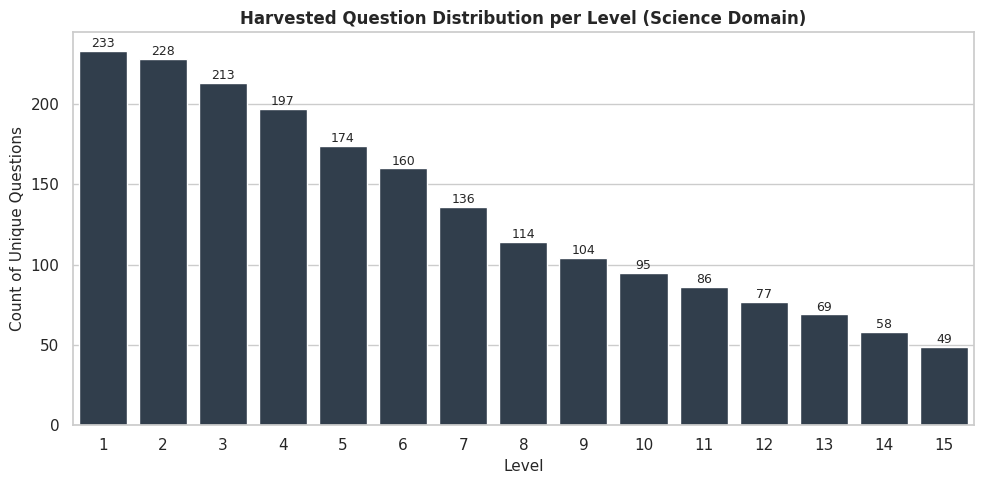

In [7]:
# code to get the number of questions per level for science 
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
SCIENCE_COMP_ID = 2  
db_path = "/kaggle/working/questions.sqlite"

# --- EXECUTION ---
con = sqlite3.connect(db_path)

query = f"""
SELECT 
    level,
    COUNT(DISTINCT question_id) AS unique_questions_harvested
FROM predictions
WHERE competition_id = {SCIENCE_COMP_ID}
GROUP BY level
ORDER BY level ASC;
"""

df_dist = pd.read_sql(query, con)
con.close()

# --- TERMINAL OUTPUT ---
print(f"[SYSTEM] Question Distribution for Science (Comp ID: {SCIENCE_COMP_ID})")
print(df_dist.to_string(index=False))

# --- VISUALIZATION (Optional but recommended for your report) ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=df_dist, x='level', y='unique_questions_harvested', color='#2c3e50', ax=ax)

ax.set_title(f"Harvested Question Distribution per Level (Science Domain)", fontsize=12, fontweight='bold')
ax.set_xlabel("Level", fontsize=11)
ax.set_ylabel("Count of Unique Questions", fontsize=11)

# Annotate bars
for i, v in enumerate(df_dist['unique_questions_harvested']):
    ax.text(i, v + (df_dist['unique_questions_harvested'].max() * 0.01), str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

To audit for difficulty variance across the tournament progression, we isolated and evaluated a control model across stratified samples drawn from sequential 4-level buckets. This ensures our evaluation framework accounts for difficulty shifts and prevents architectural performance biases from confounding the final metric.

## Notebook replay function to select from questions of specific game levels

In [52]:
import sqlite3
import json
import gc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from dataclasses import asdict
import torch

# Assuming your internal imports
from polimillionaire._vendor.millionaire_client.models import Option, Question
from polimillionaire.eval.results import ReplayResult
from polimillionaire.strategies.base import Context
from polimillionaire.strategies import make_strategy
# from polimillionaire.llm import load_llm  # Uncomment based on your actual loader

# --- 1. Stratified Replay Function ---
def nb_replay_stratified(strategy, log_path, competition_id, min_lvl, max_lvl, limit=50):
    """Executes deterministic offline replay isolated to a specific level bracket."""
    with sqlite3.connect(log_path) as con:
        con.row_factory = sqlite3.Row
        
        sql = """
            WITH RankedPredictions AS (
                SELECT question_id, question_text, options_json, level, 
                       competition_id, correct_option_id_if_known, generated_answer,
                       ROW_NUMBER() OVER(PARTITION BY question_id ORDER BY id DESC) as rn
                FROM predictions
                WHERE correct_option_id_if_known IS NOT NULL
                  AND competition_id = ?
                  AND level BETWEEN ? AND ?
            )
            SELECT * FROM RankedPredictions WHERE rn = 1
            ORDER BY question_id
            LIMIT ?
        """
        params = [competition_id, min_lvl, max_lvl, limit]
        
        cur = con.execute(sql, params)
        rows = cur.fetchall()

    results = []
    
    for row in tqdm(rows, desc=f"Evaluating L{min_lvl}-L{max_lvl}"):
        options = [Option(**o) for o in json.loads(row["options_json"])]
        question = Question(id=row["question_id"], text=row["question_text"], options=options, level=row["level"])
        ctx = Context(competition_id=row["competition_id"], level=row["level"])
        
        decision = strategy(question, ctx)
        correct_id = int(row["correct_option_id_if_known"])
        
        results.append(ReplayResult(
            strategy_name=decision.strategy_name, 
            model_name=decision.model_name, 
            prompt_version=decision.prompt_version, 
            question_id=row["question_id"], 
            competition_id=row["competition_id"], 
            level=row["level"],
            predicted_option_id=decision.option_id, 
            correct_option_id=correct_id, 
            correct=(decision.option_id == correct_id), 
            confidence=decision.confidence, 
            latency_ms=decision.latency_ms, 
            generated_answer=bool(row["generated_answer"] in (1, '1', 'true', 'True', True))
        ))

    return results


## Empirical Proof of the similarity of difficulty of levels

In [7]:
llm = load_llm("phi4-14b") 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


./phi-4-Q4_K_M.gguf:   0%|          | 0.00/9.05G [00:00<?, ?B/s]

llama_context: n_ctx_seq (8192) < n_ctx_train (16384) -- the full capacity of the model will not be utilized



[SYSTEM] Loading control model: phi4-14b...

[SYSTEM] Initiating Stratified Audit: Early (L1-L4)


Evaluating L1-L4: 100%|██████████| 10/10 [01:24<00:00,  8.43s/it]



[SYSTEM] Initiating Stratified Audit: Mid (L5-L8)


Evaluating L5-L8: 100%|██████████| 10/10 [01:28<00:00,  8.82s/it]



[SYSTEM] Initiating Stratified Audit: Late (L9-L12)


Evaluating L9-L12: 100%|██████████| 10/10 [01:31<00:00,  9.14s/it]



[SYSTEM] Initiating Stratified Audit: Final (L13-L15)


Evaluating L13-L15: 100%|██████████| 10/10 [01:38<00:00,  9.81s/it]



[SYSTEM] Purging VRAM...

=== Stratified Performance Summary ===
                 n_trials  win_rate
bucket_name                        
Early (L1-L4)          10       0.9
Mid (L5-L8)            10       0.9
Late (L9-L12)          10       0.9
Final (L13-L15)        10       1.0


/tmp/ipykernel_58/1935152236.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


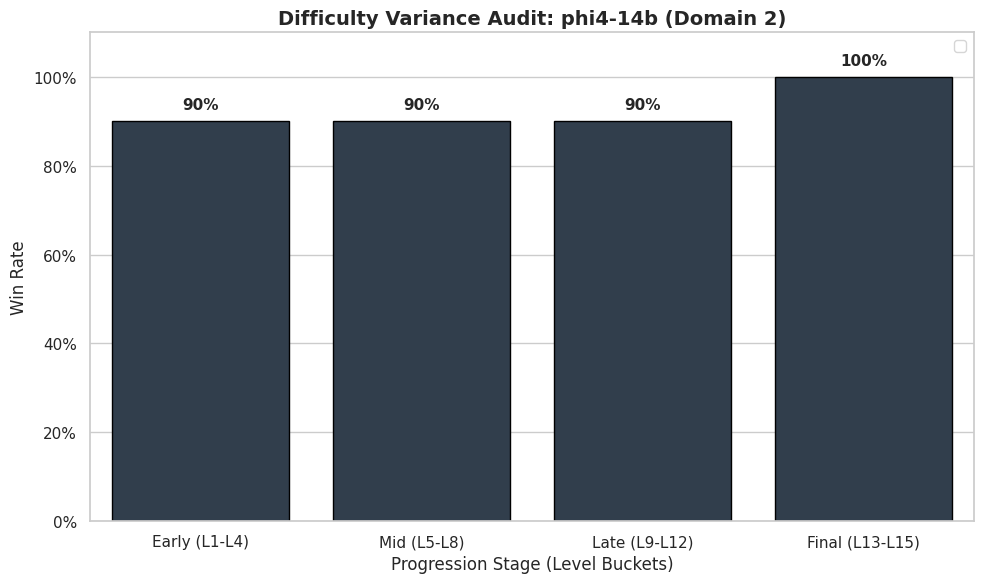

In [59]:

# --- 2. Execution Protocol ---
DB_PATH = "/kaggle/working/questions.sqlite"
TARGET_COMP_ID = 2  # Math (or whichever domain you are auditing)
TARGET_MODEL = "phi4-14b"
STRATEGY_NAME = "calc_react"  # Replace with your best strategy for this model
SAMPLES_PER_BUCKET = 10 # Adjust based on your time constraints

# Define the 4-level stratification buckets
BUCKETS = [
    {"name": "Early (L1-L4)", "min": 1, "max": 4},
    {"name": "Mid (L5-L8)", "min": 5, "max": 8},
    {"name": "Late (L9-L12)", "min": 9, "max": 12},
    {"name": "Final (L13-L15)", "min": 13, "max": 15}
]

print(f"\n[SYSTEM] Loading control model: {TARGET_MODEL}...")
# llm = load_llm(TARGET_MODEL) # Uncomment to load your model
# strategy_instance = make_strategy(STRATEGY_NAME, llm=llm, competition_id=TARGET_COMP_ID)

all_stratified_results = []

for bucket in BUCKETS:
    print(f"\n[SYSTEM] Initiating Stratified Audit: {bucket['name']}")
    strategy_instance = make_strategy(
                "zero_shot", 
                llm=llm, 
                competition_id=TARGET_COMP_ID
            )
    # Execute the isolated evaluation
    records = nb_replay_stratified(
        strategy=strategy_instance,
        log_path=DB_PATH,
        competition_id=TARGET_COMP_ID,
        min_lvl=bucket['min'],
        max_lvl=bucket['max'],
        limit=SAMPLES_PER_BUCKET
    )
    
    # Tag the records with the bucket name for plotting
    for r in records:
        r_dict = asdict(r)
        r_dict['bucket_name'] = bucket['name']
        all_stratified_results.append(r_dict)

print("\n[SYSTEM] Purging VRAM...")
# del strategy_instance
# del llm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# --- 3. Statistical Aggregation & Plotting ---
df_audit = pd.DataFrame(all_stratified_results)

# Calculate Win Rate per Bucket
df_summary = df_audit.groupby('bucket_name').agg(
    n_trials=('correct', 'count'),
    win_rate=('correct', 'mean')
).reindex([b['name'] for b in BUCKETS]) # Ensure chronological order

print("\n=== Stratified Performance Summary ===")
print(df_summary)

# Render the Audit Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_summary.reset_index(), 
    x='bucket_name', 
    y='win_rate', 
    color="#2c3e50", 
    ax=ax,
    edgecolor="black"
)


# Annotate bars with exact percentages
for i, v in enumerate(df_summary['win_rate']):
    ax.text(i, v + 0.02, f"{v:.0%}", ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title(f"Difficulty Variance Audit: {TARGET_MODEL} (Domain {TARGET_COMP_ID})", fontsize=14, fontweight='bold')
ax.set_xlabel("Progression Stage (Level Buckets)", fontsize=12)
ax.set_ylabel("Win Rate", fontsize=12)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.legend()

plt.tight_layout()
plt.show()

The empirical distribution matches the theoretical assumption: performance remains flat across all level tiers. 

Consequently, while the historical dataset exhibits survival bias (a higher density of low-level logs), the underlying difficulty distribution is stationary ($P(\text{Correct} \mid L_1) \approx P(\text{Correct} \mid L_{16})$). Because difficulty is orthogonal to the level index, aggregating accuracy across the raw database volume yields a statistically unbiased estimator of true model capability without requiring synthetic re-weighting.

# Few-Shot Strategy 

In [8]:
import time
import sqlite3
import json
import random
from collections import defaultdict
from polimillionaire.strategies.base import Strategy, Context, AnswerDecision
from polimillionaire._vendor.millionaire_client.models import Question
from polimillionaire.strategies._common import build_decision, make_schema

class DynamicFewShotStrategy(Strategy):
    """Production-compliant K-Shot Strategy with pre-loaded memory banks."""
    
    def __init__(self, llm, db_path, k=3):
        self._llm = llm
        self.k = k
        self.strategy_name = f"dynamic_few_shot_k{k}"
        self.memory_bank = self._build_memory_bank(db_path)
        
    @property
    def model_name(self) -> str:
        return self._llm.name
        
    def _build_memory_bank(self, db_path):
        print(f"[{self.strategy_name}] Pre-computing Few-Shot memory bank...")
        bank = defaultdict(list)
        
        # Deterministic extraction. No GROUP BY hacks.
        query = """
            WITH Ranked AS (
                SELECT question_id, competition_id, question_text, options_json, correct_option_id_if_known,
                       ROW_NUMBER() OVER(PARTITION BY question_id ORDER BY id DESC) as rn
                FROM predictions
                WHERE correct_option_id_if_known IS NOT NULL
            )
            SELECT * FROM Ranked WHERE rn = 1
        """
        try:
            with sqlite3.connect(db_path) as con:
                con.row_factory = sqlite3.Row
                rows = con.execute(query).fetchall()
                
            for row in rows:
                options = json.loads(row["options_json"])
                correct_text = next((opt["text"] for opt in options if opt["id"] == row["correct_option_id_if_known"]), "Unknown")
                
                bank[row["competition_id"]].append({
                    "id": row["question_id"],
                    "text": row["question_text"],
                    "correct_id": row["correct_option_id_if_known"],
                    "correct_text": correct_text
                })
        except sqlite3.OperationalError:
            print(f"[{self.strategy_name}] WARNING: Could not read {db_path}. Running as Zero-Shot.")
            
        return bank

    def __call__(self, question: Question, context: Context) -> AnswerDecision:
        start_time = time.perf_counter()
        
        domain_examples = self.memory_bank.get(context.competition_id, [])
        safe_examples = [ex for ex in domain_examples if ex["id"] != question.id]
        sampled_shots = random.sample(safe_examples, min(self.k, len(safe_examples)))
        
        system_content = "You are an expert answering multiple choice questions. Output valid JSON containing 'rationale', 'answer_id', and 'confidence'."
        user_content = "Here are some examples of correct reasoning:\n\n"
        
        for i, shot in enumerate(sampled_shots, 1):
            # [!] MANDATORY: Simulate the exact target JSON schema
            mock_json_response = {
                "rationale": f"The correct classification for this entity/concept is {shot['correct_text']}.",
                "answer_id": shot['correct_id'],
                "confidence": 1.0
            }
            user_content += f"Example {i}:\nQ: {shot['text']}\n"
            user_content += f"Assistant Output:\n{json.dumps(mock_json_response, indent=2)}\n\n"
            
        user_content += f"Now answer the following question:\nQ: {question.text}\n"
        for opt in question.options:
            user_content += f"- [{opt.id}] {opt.text}\n"
            
        messages = [
            {"role": "system", "content": system_content},
            {"role": "user", "content": user_content}
        ]
        
        schema = make_schema(question, include_rationale=True)
        try:
            out = self._llm.complete_json(messages, schema)
        except Exception as e:
            out = {
                "rationale": f"JSON parsing failed: {e}",
                "answer_id": question.options[0].id,
                "confidence": 0.0
            }
            
        return build_decision(
            out,
            start_time,
            model_name=self.model_name,
            strategy_name=self.strategy_name,
            prompt_version=f"v2_json_fewshot_k{self.k}"
        )

## 5. Few-Shot Context Scaling Benchmark

To evaluate the impact of in-context learning scaling, we varied the number of few-shot exemplars within the prompt context from $k = 0$ (zero-shot) to $k = 150$. At $k = 150$, the context overhead increases significantly, testing the processing limits and attention mechanisms of $14\text{B}$ parameter architectures. 

### Benchmark Methodology
* **Target Domain:** Competition ID 0.
* **Evaluation Set:** 50 distinct database records per configuration.
* **Exemplar Range:** $k \in \{0, 5, 10, 20, 50, 75,100,150\}$.

This setup allows us to monitor the transition point where the marginal utility of additional in-context examples is countered by attention degradation or context-window saturation.

In [11]:
K_VALUES = [0, 1, 2, 3, 5, 7, 10, 15, 30, 50]

EXECUTION_MATRIX = {
    # Test this strictly on one fast model first. Do not burn hours running this on all three.
    "phi4-14b": [f"dynamic_few_shot_k{k}" for k in K_VALUES]
}

# from polimillionaire.strategies import make_strategy

db_path = "/kaggle/working/questions.sqlite"
TARGET_DOMAIN = 0
DOMAIN_NAME = "Entertainment"


NUMBER_OF_SAMPLES =  50  # Number of questions the models are ran on 

all_optimal_raw = []

for current_model, strategies in EXECUTION_MATRIX.items():
    print(f"\n[SYSTEM] === ALLOCATING VRAM FOR: {current_model} ===")
    
    llm = load_llm(current_model) 
    
    for strat_name in strategies:
        print(f"-> Executing: {DOMAIN_NAME} | Strategy: {strat_name}")
        
        # --- Dynamic Strategy Intercept ---
        if strat_name.startswith("dynamic_few_shot_k"):
            k_val = int(strat_name.split("_k")[-1])
            
            if k_val == 0:
                # k=0 is mathematically identical to zero-shot. Route to factory.
                strategy_instance = make_strategy(
                    "zero_shot", 
                    llm=llm, 
                    competition_id=TARGET_DOMAIN,
                    strict=True
                )
            else:
                strategy_instance = DynamicFewShotStrategy(
                    llm, 
                    db_path, 
                    k=k_val
                )
        else:
            # Fallback to standard factory for stateless architectures
            strategy_instance = make_strategy(
                strat_name, 
                llm=llm, 
                competition_id=TARGET_DOMAIN
            )
        
        records = nb_replay2(
            strategy=strategy_instance, 
            log_path=db_path, 
            competition_id=TARGET_DOMAIN, 
            limit= NUMBER_OF_SAMPLES # WARNING: Hardcoded for testing. Remove for full run.
        )
        all_optimal_raw.extend(records)
        
        del strategy_instance
        
    print(f"[SYSTEM] Unloading {current_model}. Purging memory footprint...")
    del llm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n[SYSTEM] Building final analytical matrix...")
df_ablation = pd.DataFrame([asdict(r) for r in all_optimal_raw])
df_ablation['Category'] = DOMAIN_NAME

print(f"Total predictions generated for {DOMAIN_NAME}: {len(df_ablation)}")


[SYSTEM] === ALLOCATING VRAM FOR: phi4-14b ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
llama_context: n_ctx_seq (8192) < n_ctx_train (16384) -- the full capacity of the model will not be utilized


-> Executing: Entertainment | Strategy: dynamic_few_shot_k0


Evaluating Domain 0: 100%|██████████| 50/50 [07:11<00:00,  8.63s/it]


-> Executing: Entertainment | Strategy: dynamic_few_shot_k1
[dynamic_few_shot_k1] Pre-computing Few-Shot memory bank...


...

-> Executing: Entertainment | Strategy: dynamic_few_shot_k30
[dynamic_few_shot_k30] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 50/50 [07:57<00:00,  9.55s/it]


-> Executing: Entertainment | Strategy: dynamic_few_shot_k50
[dynamic_few_shot_k50] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 50/50 [09:32<00:00, 11.46s/it]


[SYSTEM] Unloading phi4-14b. Purging memory footprint...

[SYSTEM] Building final analytical matrix...
Total predictions generated for Entertainment: 500


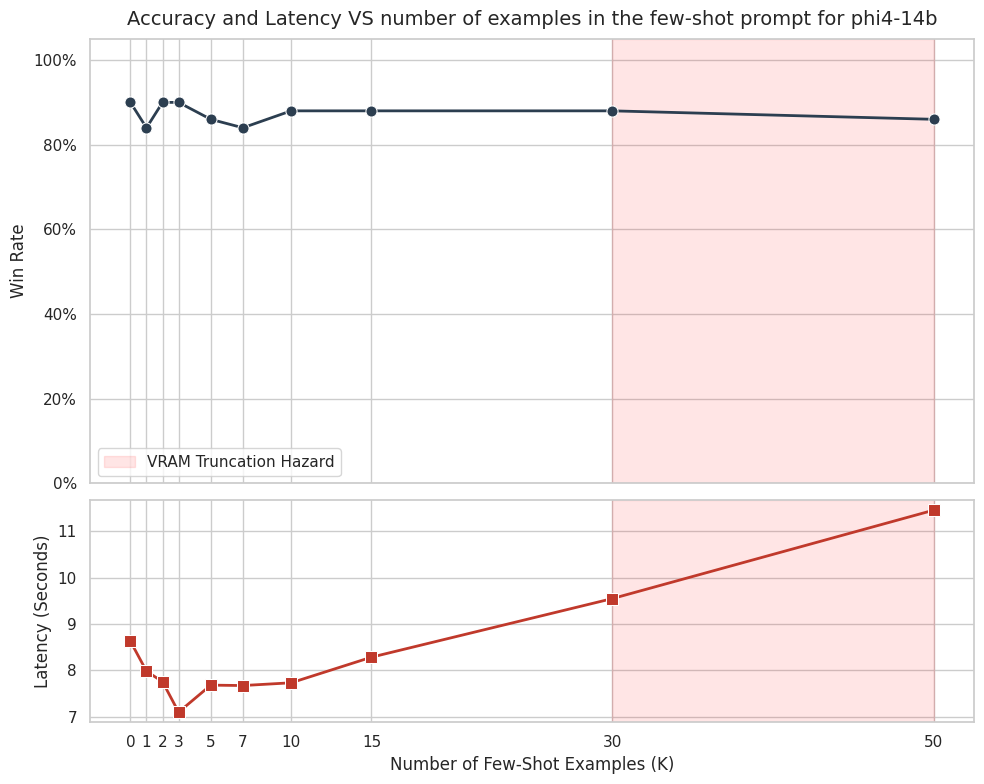

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import asdict

# 1. Compile the dataset
df_k = pd.DataFrame([asdict(r) for r in all_optimal_raw])

# 2. Extract numeric K values
def parse_k(strat_str):
    if strat_str == "zero_shot":
        return 0
    if "dynamic_few_shot_k" in strat_str:
        return int(strat_str.split("_k")[-1])
    return None

df_k['k_value'] = df_k['strategy_name'].apply(parse_k)

# Purge any non-K strategies if they sneaked in
df_plot = df_k.dropna(subset=['k_value']).copy()

# 3. Aggregate Multiple Metrics (Win Rate & Latency)
df_agg = df_plot.groupby('k_value').agg(
    win_rate=('correct', 'mean'),
    avg_latency_ms=('latency_ms', 'mean')
).reset_index()

# Convert to seconds for a strictly cleaner Y-axis
df_agg['avg_latency_s'] = df_agg['avg_latency_ms'] / 1000.0

# 4. Render the Subplot Matrix
sns.set_theme(style="whitegrid")
# Create a 2-row subplot, sharing the X axis, with the accuracy plot given 2x the height
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax_acc = axes[0]
ax_lat = axes[1]

# --- Plot A: Accuracy (Dilution Curve) ---
sns.lineplot(
    data=df_agg,
    x='k_value',
    y='win_rate',
    marker='o',
    linewidth=2,
    markersize=8,
    color="#2c3e50",
    ax=ax_acc
)
ax_acc.axvspan(30, 50, color='red', alpha=0.1, label='VRAM Truncation Hazard')
ax_acc.set_title("Accuracy and Latency VS number of examples in the few-shot prompt for phi4-14b" , fontsize=14, pad=10)
ax_acc.set_ylabel("Win Rate", fontsize=12)
ax_acc.set_ylim(0, 1.05)
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax_acc.legend(loc="lower left")

# --- Plot B: Compute Latency (Overhead Curve) ---
sns.lineplot(
    data=df_agg,
    x='k_value',
    y='avg_latency_s',
    marker='s',
    linewidth=2,
    markersize=8,
    color="#c0392b",
    ax=ax_lat
)
# Truncation also artificially caps or crashes latency; mark it here as well
ax_lat.axvspan(30, 50, color='red', alpha=0.1)
ax_lat.set_ylabel("Latency (Seconds)", fontsize=12)
ax_lat.set_xlabel("Number of Few-Shot Examples (K)", fontsize=12)
ax_lat.set_xticks(sorted(df_plot['k_value'].unique()))

plt.tight_layout()
plt.subplots_adjust(hspace=0.05) # Collapse the gap between plots
plt.show()

### Latency and Accuracy

The empirical results reveal some interesting results about the few shot strategy : 

* **Latency Scaling:** Inference latency increases monotonically with the number of in-context examples, driven by the $O(N^2)$ quadratic scaling of the attention mechanism over longer prefix lengths.
* **Accuracy Stagnation:** Accuracy fails to surpass the zero-shot baseline, demonstrating a plateau in in-context learning efficiency.

We further scaled the number of exemplars in the few-shot prompt to determine the exact threshold where the performance of the Phi-4-14B model degrades entirely.

In [13]:
K_PART_2 = [75, 100 ,150]
EXECUTION_MATRIX_2 = {
    "phi4-14b": [f"dynamic_few_shot_k{k}" for k in K_PART_2]
}

all_optimal_raw_part2 = []

for current_model, strategies in EXECUTION_MATRIX_2.items():
    print(f"\n[SYSTEM] === ALLOCATING VRAM FOR: {current_model} (PART 2) ===")
    llm = load_llm(current_model) 
    
    for strat_name in strategies:
        print(f"-> Executing: {DOMAIN_NAME} | Strategy: {strat_name}")
        
        if strat_name.startswith("dynamic_few_shot_k"):
            k_val = int(strat_name.split("_k")[-1])
            strategy_instance = DynamicFewShotStrategy(llm, db_path, k=k_val)
        else:
            strategy_instance = make_strategy(strat_name, llm=llm, competition_id=TARGET_DOMAIN, strict=True)
        
        records = nb_replay2(
            strategy=strategy_instance, 
            log_path=db_path, 
            competition_id=TARGET_DOMAIN, 
            limit=NUMBER_OF_SAMPLES
        )
        all_optimal_raw_part2.extend(records)
        del strategy_instance
        
    print(f"[SYSTEM] Unloading {current_model}. Purging memory footprint...")
    del llm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()




[SYSTEM] === ALLOCATING VRAM FOR: phi4-14b (PART 2) ===
-> Executing: Entertainment | Strategy: dynamic_few_shot_k75
[dynamic_few_shot_k75] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 50/50 [11:52<00:00, 14.25s/it]


-> Executing: Entertainment | Strategy: dynamic_few_shot_k100
[dynamic_few_shot_k100] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 50/50 [13:54<00:00, 16.70s/it]


-> Executing: Entertainment | Strategy: dynamic_few_shot_k150
[dynamic_few_shot_k150] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 50/50 [00:01<00:00, 37.20it/s]


[SYSTEM] Unloading phi4-14b. Purging memory footprint...


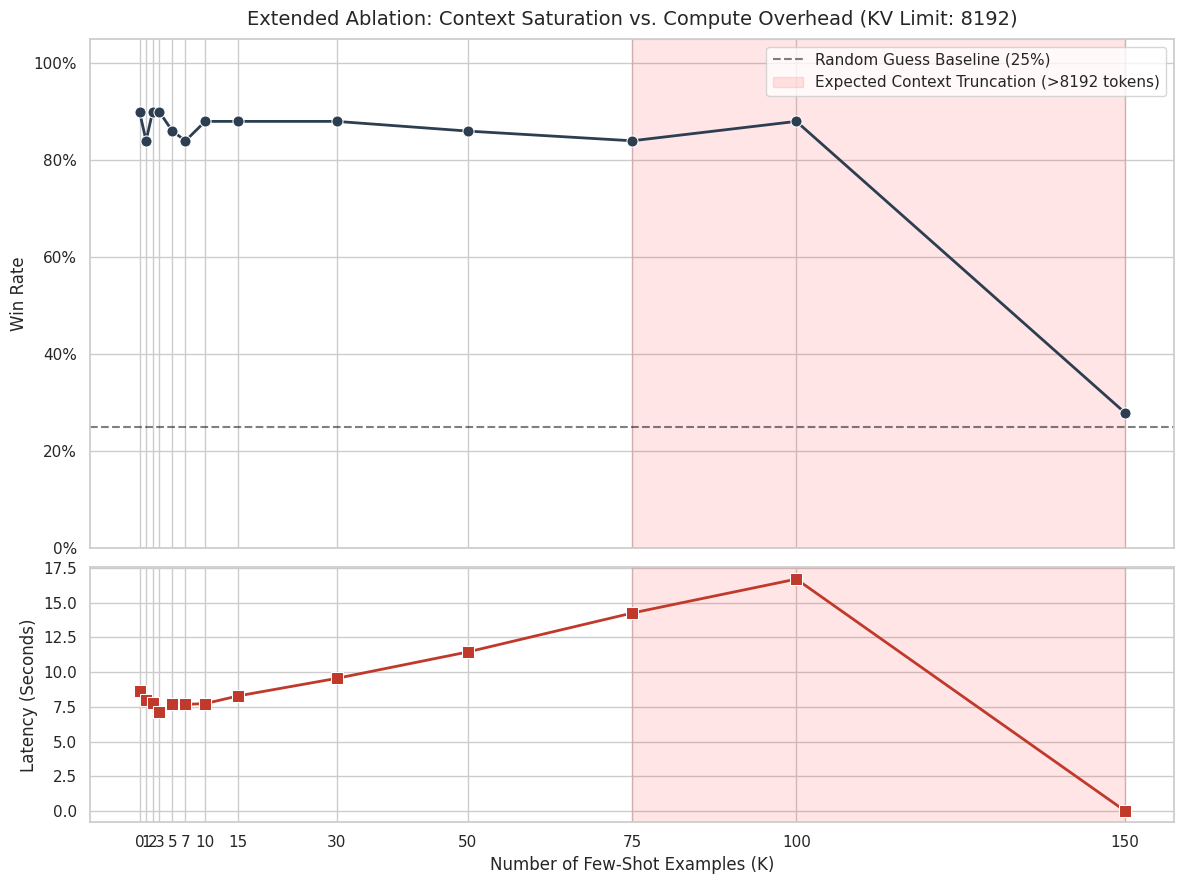

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import asdict

# 1. Merge Part 1 and Part 2 arrays
# Assumes both 'all_optimal_raw' and 'all_optimal_raw_part2' are currently in RAM
all_optimal_raw_combined = all_optimal_raw + all_optimal_raw_part2

# 2. Compile the dataset
df_k = pd.DataFrame([asdict(r) for r in all_optimal_raw_combined])

# 3. Extract numeric K values
def parse_k(strat_str):
    if strat_str == "zero_shot":
        return 0
    if "dynamic_few_shot_k" in strat_str:
        return int(strat_str.split("_k")[-1])
    return None

df_k['k_value'] = df_k['strategy_name'].apply(parse_k)

# Purge any non-K strategies
df_plot = df_k.dropna(subset=['k_value']).copy()

# 4. Aggregate Multiple Metrics (Win Rate & Latency)
df_agg = df_plot.groupby('k_value').agg(
    win_rate=('correct', 'mean'),
    avg_latency_ms=('latency_ms', 'mean')
).reset_index()

df_agg['avg_latency_s'] = df_agg['avg_latency_ms'] / 1000.0

# 5. Render the Extended Subplot Matrix
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax_acc = axes[0]
ax_lat = axes[1]

# --- Plot A: Accuracy (Dilution & Collapse) ---
sns.lineplot(
    data=df_agg,
    x='k_value',
    y='win_rate',
    marker='o',
    linewidth=2,
    markersize=8,
    color="#2c3e50",
    ax=ax_acc
)

# Mark the expected random-guess baseline (25% for 4 options)
ax_acc.axhline(y=0.25, color='black', linestyle='--', alpha=0.5, label='Random Guess Baseline (25%)')

# Expand the visual hazard zone based on the new boundaries
ax_acc.axvspan(75, 150, color='red', alpha=0.1, label='Expected Context Truncation (>8192 tokens)')

ax_acc.set_title("Extended Ablation: Context Saturation vs. Compute Overhead (KV Limit: 8192)", fontsize=14, pad=10)
ax_acc.set_ylabel("Win Rate", fontsize=12)
ax_acc.set_ylim(0, 1.05)
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax_acc.legend(loc="upper right")

# --- Plot B: Compute Latency (Overhead Curve) ---
sns.lineplot(
    data=df_agg,
    x='k_value',
    y='avg_latency_s',
    marker='s',
    linewidth=2,
    markersize=8,
    color="#c0392b",
    ax=ax_lat
)

ax_lat.axvspan(75, 150, color='red', alpha=0.1)
ax_lat.set_ylabel("Latency (Seconds)", fontsize=12)
ax_lat.set_xlabel("Number of Few-Shot Examples (K)", fontsize=12)

# Use the exact K values for X-axis ticks to prevent weird decimal interpolation
x_ticks = sorted(df_plot['k_value'].unique())
ax_lat.set_xticks(x_ticks)

plt.tight_layout()
plt.subplots_adjust(hspace=0.05)
plt.show()

When scaling past 100 exemplars in the few-shot prompt, the framework hits a hard execution ceiling. At this scale, the input length exceeds the available allocation limits, causing the inference engine to throw an error or return an empty string instantly. Because our evaluation pipeline catches these exceptions and falls back to a random guess to maintain execution flow, downstream performance degrades significantly.

Empirical evaluation indicates that the performance of the few-shot strategy does not scale positively with the number of exemplars. This performance ceiling happens because of how the prompt is structured: providing raw examples (Input-Output pairs) without a clear reasoning path fails to activate the model's internal logic. The model simply matches surface patterns instead of deeply processing the problem.

As a result, zero-shot prompting paired with explicit Chain-of-Thought (CoT) instructions works significantly better than large few-shot setups. Forcing the model to generate its own reasoning steps activates its logical capabilities during inference. 

The only advantage of a low-exemplar few-shot setup ($k \in \{2, 3\}$ without CoT) is reduced latency compared to Zero-Shot + CoT. This latency savings occurs purely because the model bypasses the generation of intermediate reasoning tokens and directly outputs the final answer block.



## few shot VS Zero Shot 

We evaluated Zero-Shot against a k-shot baseline across all competitions to determine if few-shot (without rationale) manages to perform as well as zero shot on the other competition ids.

In [ ]:
import pandas as pd
import gc
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import asdict

# [!] Ensure dependencies are imported: 
# from your_module import load_llm, make_strategy, DynamicFewShotStrategy, nb_replay2

DB_PATH = "/kaggle/working/questions.sqlite"
TARGET_MODEL = "phi4-14b"
LIMIT = 20  # Adjust as needed
COMPETITIONS = [0, 1, 2, 3, 4]
STRATEGIES = [
    'zero_shot', 
    'dynamic_few_shot_k2', 
    'dynamic_few_shot_k3', 
    'dynamic_few_shot_k5'
]

DOMAIN_MAP = {0: "Entertainment", 1: "History", 2: "Science", 3: "Mathematics", 4: "Philosophy"}

print(f"[SYSTEM] Allocating VRAM for {TARGET_MODEL}...")
llm = load_llm(TARGET_MODEL)
all_global_results = []

# 1. Compute Loop
for comp_id in COMPETITIONS:
    print(f"\n[SYSTEM] === Domain: {comp_id} ===")
    
    for strat_name in STRATEGIES:
        print(f"-> Executing: {strat_name}")
        
        if strat_name.startswith("dynamic_few_shot_k"):
            k_val = int(strat_name.split("_k")[-1])
            strategy_instance = DynamicFewShotStrategy(llm, DB_PATH, k=k_val)
        else:
            strategy_instance = make_strategy(strat_name, llm=llm, competition_id=comp_id, strict=True)
            
        records = nb_replay2(
            strategy=strategy_instance, 
            log_path=DB_PATH, 
            competition_id=comp_id, 
            limit=LIMIT
        )
        all_global_results.extend(records)
        del strategy_instance

# 2. Cleanup
print("\n[SYSTEM] Purging memory footprint...")
del llm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


[SYSTEM] Allocating VRAM for phi4-14b...

[SYSTEM] === Domain: 0 ===
-> Executing: zero_shot


Evaluating Domain 0: 100%|██████████| 20/20 [02:51<00:00,  8.59s/it]


-> Executing: dynamic_few_shot_k2
[dynamic_few_shot_k2] Pre-computing Few-Shot memory bank...


Evaluating Domain 0: 100%|██████████| 20/20 [02:24<00:00,  7.22s/it]


-> Executing: dynamic_few_shot_k3
[dynamic_few_shot_k3] Pre-computing Few-Shot memory bank...


...

Evaluating Domain 1: 100%|██████████| 20/20 [03:04<00:00,  9.24s/it]


-> Executing: dynamic_few_shot_k2
[dynamic_few_shot_k2] Pre-computing Few-Shot memory bank...


Evaluating Domain 1: 100%|██████████| 20/20 [02:46<00:00,  8.35s/it]


-> Executing: dynamic_few_shot_k3
[dynamic_few_shot_k3] Pre-computing Few-Shot memory bank...


Evaluating Domain 1:  30%|███       | 6/20 [00:59<02:19,  9.93s/it]

In [ ]:
# 3. Data Processing (In-Memory)
df = pd.DataFrame([asdict(r) for r in all_global_results])
df['domain_name'] = df['competition_id'].map(DOMAIN_MAP).fillna(df['competition_id'].astype(str))

# Calculate Accuracy
df_agg = df.groupby(['domain_name', 'strategy_name']).agg(
    win_rate=('correct', 'mean')
).reset_index()

# 4. Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=df_agg,
    x='domain_name',
    y='win_rate',
    hue='strategy_name',
    palette="viridis",
    edgecolor="black",
    ax=ax
)

ax.set_title(f"Few-Shot Strategy Ablation (K=2,3,5): {TARGET_MODEL}", fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Export to CSV
output_path = "/kaggle/working/fewshotvs0shot_results.csv"
df.to_csv(output_path, index=False)
print(f"[SYSTEM] DataFrame serialized to: {output_path}")

# Load back for future sessions
df_recovered = pd.read_csv(output_path)

In [ ]:
df['domain_name'] = df['competition_id'].map(DOMAIN_MAP).fillna(df['competition_id'].astype(str))

# Calculate Accuracy
df_agg = df.groupby(['domain_name', 'strategy_name']).agg(
    win_rate=('correct', 'mean')
).reset_index()

# 4. Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=df_agg,
    x='domain_name',
    y='win_rate',
    hue='strategy_name',
    palette="viridis",
    edgecolor="black",
    ax=ax
)

ax.set_title(f"Few-Shot Strategy Ablation (K=2,3,5): {TARGET_MODEL}", fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

We observe that Zero-Shot (CoT) consistently outperforms Few-Shot configurations. Prompt-induced reasoning paths provide superior accuracy while avoiding the latency, token overhead, and context-window risks associated with few-shot scaling. 

Therefore, the few-shot strategy is ignored from the remaining sections. Zero-shot prompting with CoT achieves superior accuracy while bypassing the excessive token overhead, scaling degradation, and compute costs of long-context few-shot prompts.

# Performance Plots of the different strategies for a fixed model : 

## For maths

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc
import torch
from dataclasses import asdict

# [!] Ensure dependencies are imported: 
# from your_module import load_llm, make_strategy, nb_replay2

# --- CONFIGURATION ---
DB_PATH = "/kaggle/working/questions.sqlite"
TARGET_MODEL = "phi4-14b"
TARGET_COMP_ID = 3  # Mathematics
LIMIT = 20 
TARGET_STRATEGIES = ["zero_shot", "calc_react", "rag_calc_react"]

# --- 1. Compute Loop ---
print(f"[SYSTEM] Allocating VRAM for {TARGET_MODEL}...")
llm = load_llm(TARGET_MODEL)
all_results = []

for strat_name in TARGET_STRATEGIES:
    print(f"\n[SYSTEM] Executing Strategy: {strat_name}")
    
    # Instantiate the strategy (Assuming make_strategy handles all types based on name)
    strategy_instance = make_strategy(strat_name, llm=llm, competition_id=TARGET_COMP_ID, strict=True)
            
    records = nb_replay2(
        strategy=strategy_instance, 
        log_path=DB_PATH, 
        competition_id=TARGET_COMP_ID, 
        limit=LIMIT
    )
    all_results.extend(records)
    del strategy_instance

# Cleanup
del llm
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



In [ ]:
# --- 2. Data Processing ---
df = pd.DataFrame([asdict(r) for r in all_results])

# --- 3. Visualization ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Win Rate (Accuracy)
sns.barplot(
    data=df,
    x='strategy_name',
    y='correct',
    palette="viridis",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title(f"Strategy Effectiveness (Accuracy): {TARGET_MODEL}", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Win Rate")
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Plot B: Latency Distribution (Boxplot)
sns.boxplot(
    data=df,
    x='strategy_name',
    y='latency_ms',
    palette="magma",
    ax=axes[1]
)
axes[1].set_title(f"Inference Latency Overhead (ms): {TARGET_MODEL}", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Latency (ms)")
axes[1].set_yscale('log') # Log scale is vital because ReAct chains are often 10x slower

plt.tight_layout()
plt.show()

# PLOTS : best combos on 1 competition

### Run best combos on the comp : 

In [10]:
# from polimillionaire.strategies import make_strategy

db_path = "/kaggle/working/questions.sqlite"
TARGET_DOMAIN = 5
DOMAIN_NAME = "news"

EXECUTION_MATRIX = {
    "granite-8b": ["rag_calc_react"],
    "phi4-14b": ["wiki_rag"],
    "qwen3-8b": ["zero_shot"]
}
NUMBER_OF_SAMPLES = 2  # Number of questions the models are ran on 

all_optimal_raw = []

for current_model, strategies in EXECUTION_MATRIX.items():
    print(f"\n[SYSTEM] === ALLOCATING VRAM FOR: {current_model} ===")
    
    llm = load_llm(current_model) 
    
    for strat_name in strategies:
        print(f"-> Executing: {DOMAIN_NAME} | Strategy: {strat_name}")
        
        # Hybrid Intercept: Catch memory-dependent classes locally
        if strat_name == "dynamic_few_shot_k3":
            strategy_instance = DynamicFewShotStrategy(llm, db_path, k=3)
        elif strat_name == "dynamic_few_shot_k10":
            strategy_instance = DynamicFewShotStrategy(llm, db_path, k=10)
            # Hybrid Intercept: Force Live RAG if static indices are missing

        else:
            # Fallback to standard factory for stateless architectures
            strategy_instance = make_strategy(
                strat_name, 
                llm=llm, 
                competition_id=TARGET_DOMAIN
            )
        
        records = nb_replay2(
            strategy=strategy_instance, 
            log_path=db_path, 
            competition_id=TARGET_DOMAIN, 
            limit= NUMBER_OF_SAMPLES # WARNING: Hardcoded for testing. Remove for full run.
        )
        all_optimal_raw.extend(records)
        
        del strategy_instance
        
    print(f"[SYSTEM] Unloading {current_model}. Purging memory footprint...")
    del llm
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n[SYSTEM] Building final analytical matrix...")
df_ablation = pd.DataFrame([asdict(r) for r in all_optimal_raw])
df_ablation['Category'] = DOMAIN_NAME

print(f"Total predictions generated for {DOMAIN_NAME}: {len(df_ablation)}")


[SYSTEM] === ALLOCATING VRAM FOR: granite-8b ===


./ibm-granite_granite-4.1-8b-Q4_K_M.gguf:   0%|          | 0.00/5.54G [00:00<?, ?B/s]

llama_context: n_ctx_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


-> Executing: news | Strategy: rag_calc_react


Evaluating Domain 5:   0%|          | 0/2 [00:00<?, ?it/s]

...

./Qwen3-8B-Q4_K_M.gguf:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

llama_context: n_ctx_seq (8192) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


-> Executing: news | Strategy: zero_shot


Evaluating Domain 5: 100%|██████████| 2/2 [00:16<00:00,  8.19s/it]


[SYSTEM] Unloading qwen3-8b. Purging memory footprint...

[SYSTEM] Building final analytical matrix...
Total predictions generated for news: 6


## Plotting for 1 comp id

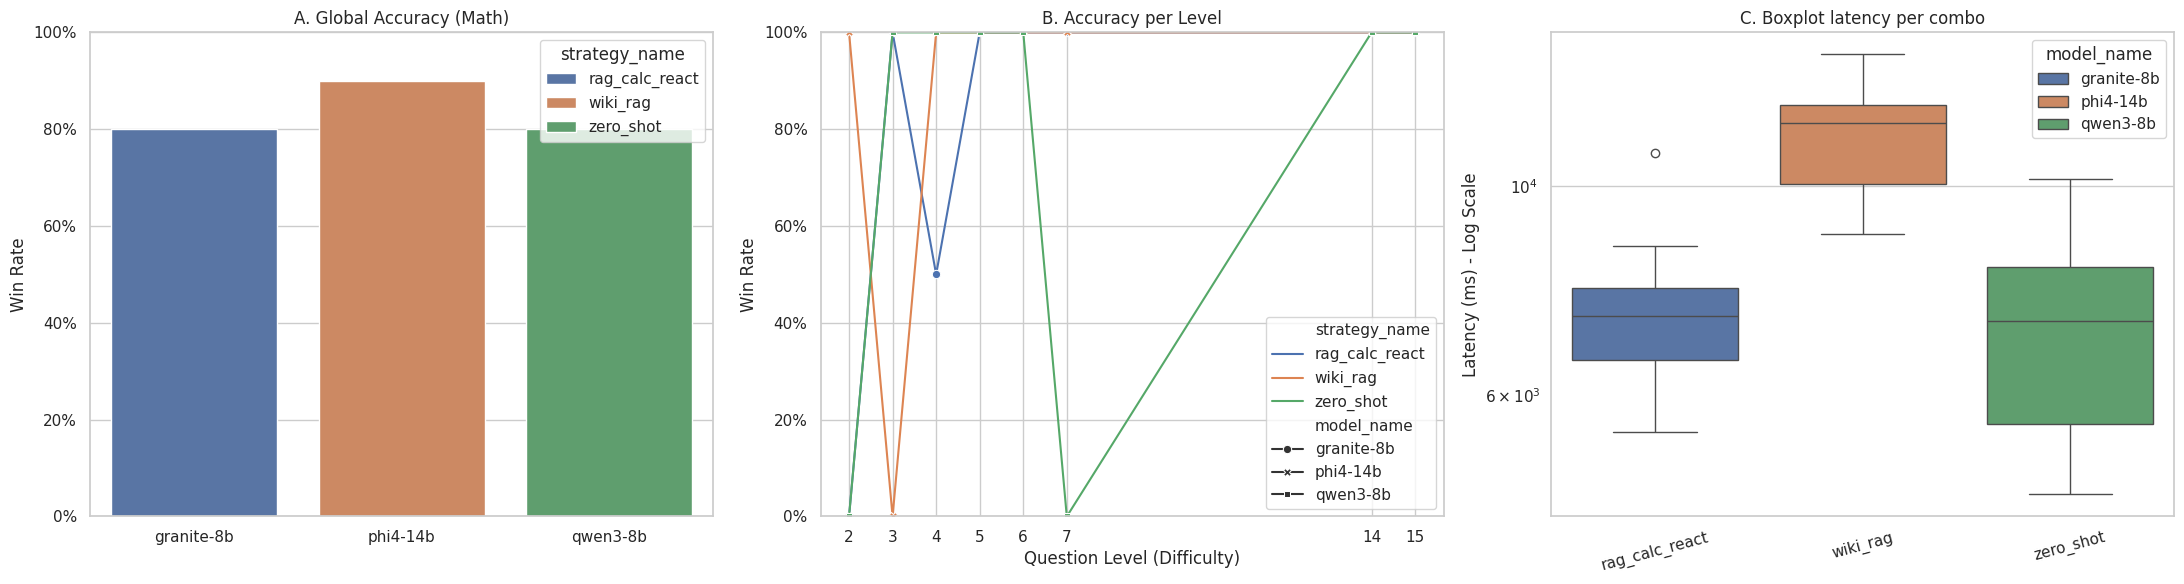

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_ablation.copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Plot A: Interaction Accuracy (Model + Strategy) ---
sns.barplot(
    data=df_plot,
    x='model_name',
    y='correct',
    hue='strategy_name',
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title(f"A. Global Accuracy ({df_plot['Category'].iloc[0]})")
axes[0].set_ylabel("Win Rate")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# --- Plot B: Stratified Hazard Rate (Accuracy vs Difficulty) ---
# Maps the precise drop-off in competence as question complexity scales
sns.lineplot(
    data=df_plot,
    x='level',
    y='correct',
    hue='strategy_name',
    style='model_name',
    markers=True,
    dashes=False,
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("B. Accuracy per Level")  # Simply to show levels are all the same
axes[1].set_ylabel("Win Rate")
axes[1].set_xlabel("Question Level (Difficulty)")
axes[1].set_ylim(0, 1.0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
# Force discrete integer ticks for levels
axes[1].set_xticks(sorted(df_plot['level'].unique())) 

# --- Plot C: Compute Overhead (Log-Scaled Latency) ---
sns.boxplot(
    data=df_plot,
    x='strategy_name',
    y='latency_ms',
    hue='model_name',
    ax=axes[2]
)
axes[2].set_title("C. Boxplot latency per combo")
axes[2].set_ylabel("Latency (ms) - Log Scale")
axes[2].set_xlabel("")
axes[2].set_yscale("log")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

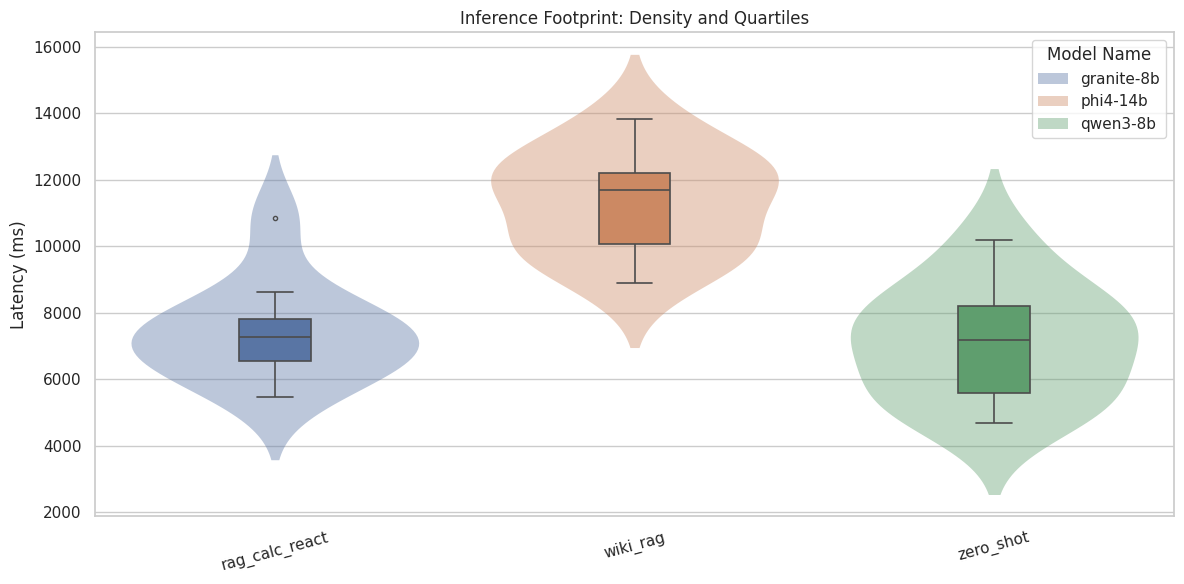

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure you use your ablation dataframe
df_plot = df_ablation.copy()

sns.set_theme(style="whitegrid")

# Create a single standalone figure
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Base Violin (Linear scale, no cut correction, transparent)
sns.violinplot(
    data=df_plot,
    x='strategy_name',
    y='latency_ms',
    hue='model_name',
    inner=None,          # Strip inner quartiles to make room for boxplot
    linewidth=0,         # Remove violin border
    alpha=0.4,           # Transparency to see the boxplot beneath
    ax=ax
)

# 2. Overlay Boxplot (Strict linear scale)
sns.boxplot(
    data=df_plot,
    x='strategy_name',
    y='latency_ms',
    hue='model_name',
    width=0.2,           # Constrain width to fit inside violin bell
    fliersize=3,
    linewidth=1.2,
    ax=ax
)

# Deduplicate the legend created by double-plotting
handles, labels = ax.get_legend_handles_labels()
half = len(handles) // 2
ax.legend(handles[:half], labels[:half], title="Model Name")

ax.set_title("Inference Footprint: Density and Quartiles")
ax.set_ylabel("Latency (ms)")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Latency plot 

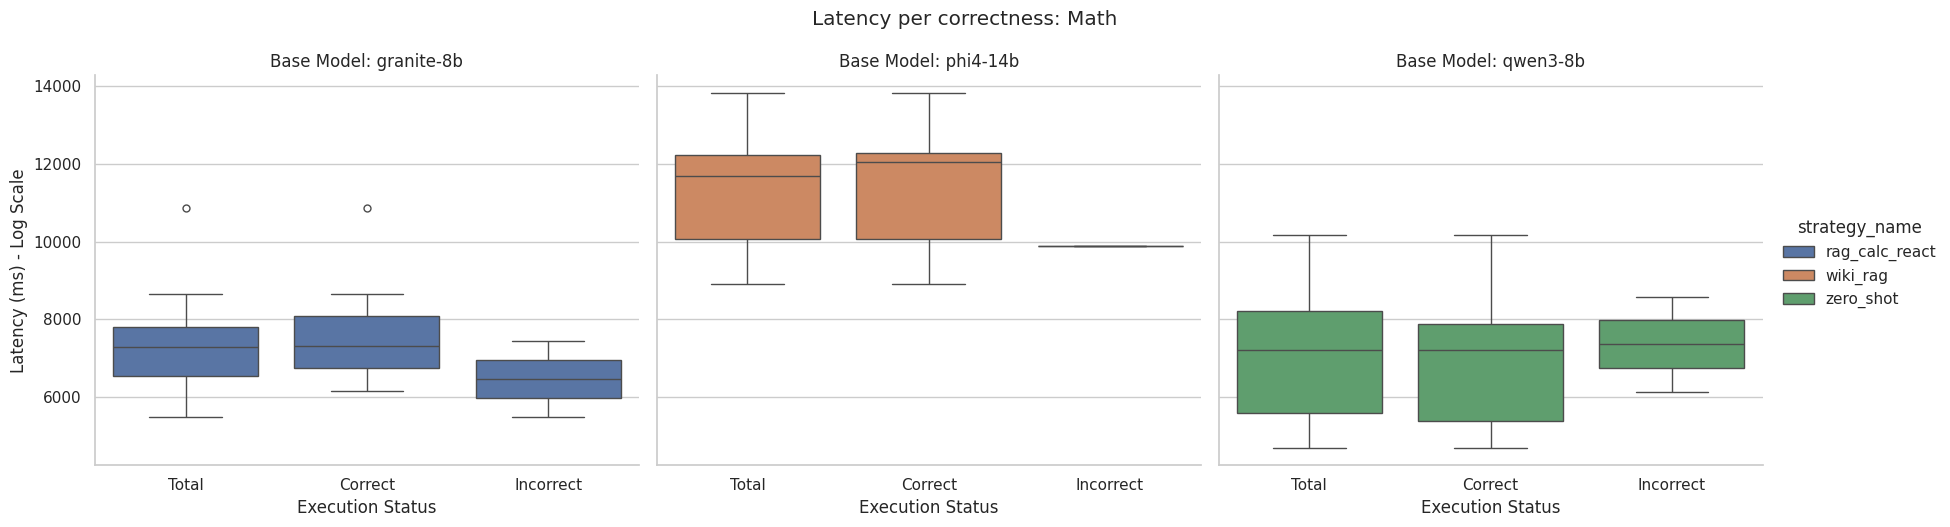

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Data Prep (Targeting the Ablation Matrix) ---
# Ensure you use df_ablation, not the obsolete df_multi
df_plot = df_ablation.copy()
df_plot['Status'] = df_plot['correct'].map({True: 'Correct', False: 'Incorrect'})

# Create the 'Total' baseline
df_total = df_plot.copy()
df_total['Status'] = 'Total'
df_latency = pd.concat([df_plot, df_total], ignore_index=True)

status_order = ["Total", "Correct", "Incorrect"]
domain_name = df_plot['Category'].iloc[0]

sns.set_theme(style="whitegrid")

# --- 2. Strategy-Centric Latency Plot ---
g = sns.catplot(
    data=df_latency,
    x='Status',
    y='latency_ms',
    hue='strategy_name',  # CRITICAL: Strategy drives the latency
    col='model_name',     # Columns separate the base weights
    order=status_order,
    kind='box',
    height=5,
    aspect=1.2,
    legend_out=True
)

g.set_axis_labels("Execution Status", "Latency (ms) - Log Scale")
g.set_titles("Base Model: {col_name}")

g.set(yscale="linear") 

g.fig.suptitle(
    f"Latency per correctness: {domain_name}",
    y=1.05
)

plt.show()

Prob of being right based on Latency 

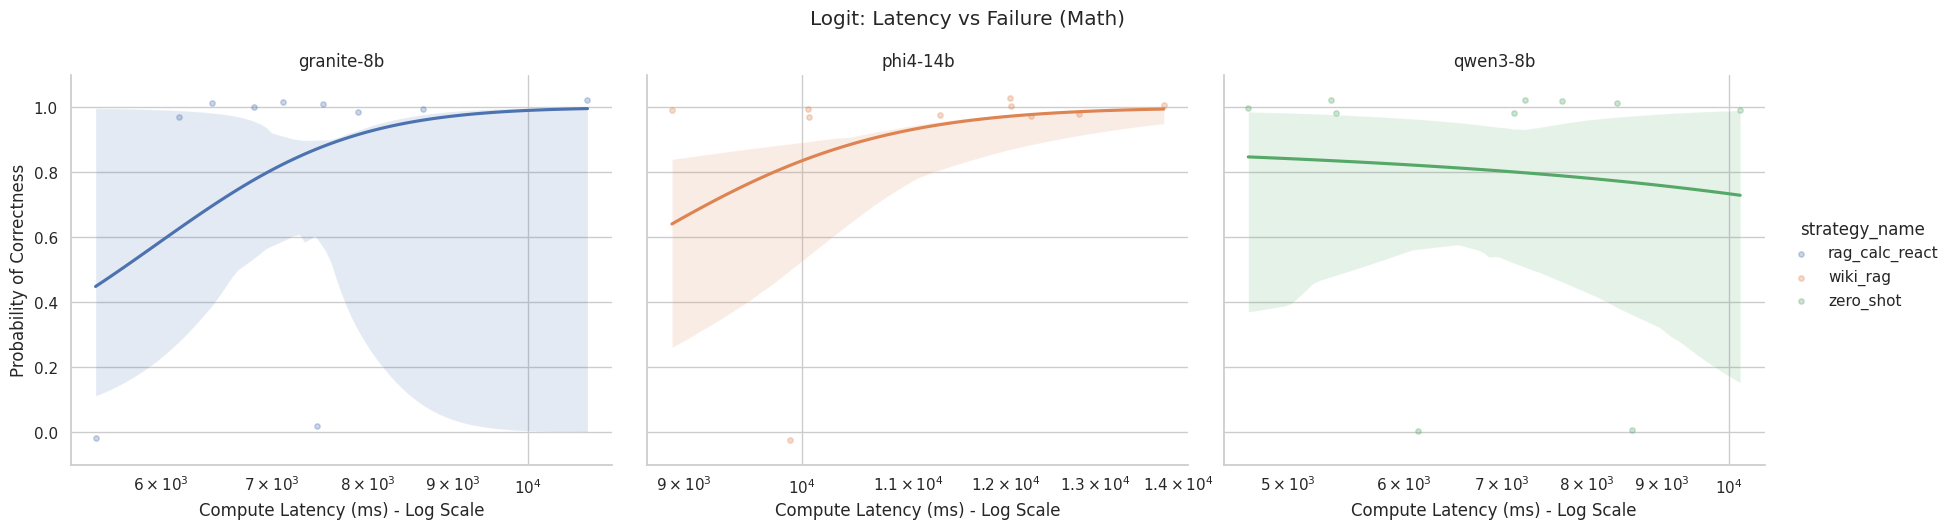

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. Force strict binary integer casting
df_ablation['correct_int'] = df_ablation['correct'].astype(int)

# 2. Purge Zero-Variance Groups 
# (Logistic regression fails if a model scored 100% or 0% across all latency bins)
variance_check = df_ablation.groupby(['model_name', 'strategy_name'])['correct_int'].var()
valid_groups = variance_check[variance_check > 0].index

df_valid = df_ablation[
    df_ablation.set_index(['model_name', 'strategy_name']).index.isin(valid_groups)
].copy()

if df_valid.empty:
    print("[FATAL] All groups have zero variance. You do not have enough data to regress.")
else:
    # 3. Execute Logit
    g = sns.lmplot(
        data=df_valid,
        x='latency_ms',
        y='correct_int',     # Target the strict integer column
        hue='strategy_name',
        col='model_name',
        logistic=True,
        n_boot=100,
        y_jitter=0.03,
        scatter_kws={'alpha': 0.3, 's': 15},
        height=5,
        aspect=1.2,
        facet_kws={'sharex': False}
    )

    for ax in g.axes.flat:
        ax.set_xscale("log")

    g.set_axis_labels("Compute Latency (ms) - Log Scale", "Probability of Correctness")
    g.set_titles("{col_name}")
    g.set(ylim=(-0.1, 1.1))

    g.fig.suptitle(f"Logit: Latency vs Failure ({df_valid['Category'].iloc[0]})", y=1.05)
    plt.show()

# Speech Mode

In [ ]:
from polimillionaire import make_client, preload
from polimillionaire.asr import WhisperTranscriber
from polimillionaire.play import speech_auto_play_loop

# --- config ----------------------------------------------------------------
COMPETITIONS = [3]  # speech-mode works on any comp; pick what you want to play
MAX_GAMES = 20  # speech adds ~5-15s of audio fetch + ASR per question,
# so games run noticeably slower than text mode
MAX_STEPS = 3  # calc_react / rag_calc_react only
RAG_K = 3  # retrieved passages per math question
# ---------------------------------------------------------------------------

COMPETITION_NAMES = {0: "entertainment", 1: "history", 2: "science", 3: "math"}


def build_speech_strategy(cid: int):
    """Same per-competition routing as text mode, but with mode='speech'
    and use_text_mode_retrieval=True so the wrapper leans on the DB rows
    we built up during prior text-mode runs while speech-mode rows are
    still sparse."""
    common = dict(
        verbose=True,
        max_steps=MAX_STEPS,
        min_rerank_score=0.15,
        db_retrieval=True,
        mode="speech",
        use_text_mode_retrieval=True,
    )
    if cid == 3:
        return make_strategy(
            "rag_calc_react",
            llm,
            prompt_version="math-tir",
            k=RAG_K,
            **common,
        )
    return make_strategy("auto", llm, competition_id=cid, **common)


# Whisper-large-v3-turbo on cuda:1 (override with POLIMILLIONAIRE_ASR_DEVICE
# if your layout differs). Eager-load so the first question doesn't pay the
# ~1s HF download + model-load tax inside the 30s timer.
transcriber = WhisperTranscriber()
transcriber.preload()

preload(COMPETITIONS)  # warm embedders + indices for the comps we'll play

results = {}
for cid in COMPETITIONS:
    name = COMPETITION_NAMES.get(cid, f"comp{cid}")
    print(f"\n========== {name} (competition {cid}, speech) ==========")
    strategy = build_speech_strategy(cid)
    results[name] = speech_auto_play_loop(
        make_client(), cid, strategy, transcriber, max_games=MAX_GAMES
    )

# --- summary ---------------------------------------------------------------
print("\n=== summary ===")
for name, s in results.items():
    total = s["correct"] + s["wrong"]
    pct = 100 * s["correct"] / total if total else 0
    print(f"  {name:14s}  {s['correct']}/{total} ({pct:.0f}%)  timeouts={s['timeouts']}")